# **Computational Urban Comfort Indexing and Annealed Optimisation for Latent Potentials**

**Authors:** Sijie Yang, Zdravko Trivic, Yihan Zhu, Mahmoud Abdelrahman, Filip Biljecki*

by Urban Analytics Lab, National University of Singapore

---

**Note:** Each .ipynb file can be run independently. This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).


# UCI Part 3: Resident and Expert Survey

This notebook isolates resident- and expert-survey processing, normalization, and comparison with causal-importance weights.

Data sources used in this notebook:
- `data/data_resident_survey_results.csv`
- `data/data_uci_dimension_causal_importance.json`

Output saved by this notebook:
- `data/data_uci_hybrid_weighting.json`


## 1. Setup and Inputs

Load survey data and define shared activity/space labels used across resident, expert, and causal outputs.


In [17]:
# 1.0 Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Columns: Index(['id', 'eating_drinking', 'nature_exploration', 'community_gathering',
       'citywalking', 'urban_sightseeing', 'streetscape_perception',
       'functionality', 'accessibility', 'contact_density', 'email', 'nus_id',
       'createdAt', 'updatedAt'],
      dtype='object')
Responses: 172
{'streetscape_perception': [3.8430232558139537, 1.9186046511627908, 3.854651162790698, 2.38953488372093, 2.994186046511628], 'functionality': [1.5174418604651163, 4.25, 2.255813953488372, 3.616279069767442, 3.36046511627907], 'accessibility': [1.7267441860465116, 4.046511627906977, 2.354651162790698, 3.372093023255814, 3.5], 'contact_density': [2.703488372093023, 3.2093023255813953, 2.645348837209302, 3.0988372093023258, 3.3430232558139537]}
{'eating_drinking': [2.86046511627907, 2.2209302325581395, 1.8546511627906976, 3.063953488372093], 'nature_exploration': [1.3953488372093024, 3.127906976744186, 2.877906976744186, 2.5988372093023258], 'community_gathering': [3.0290697674418605, 2.33

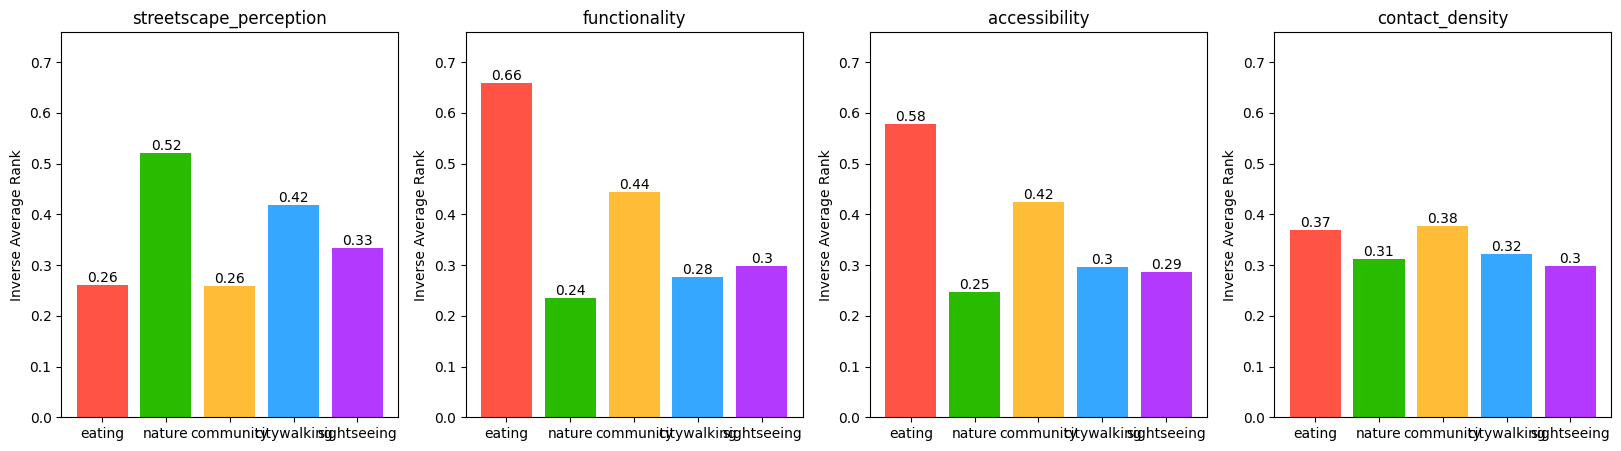

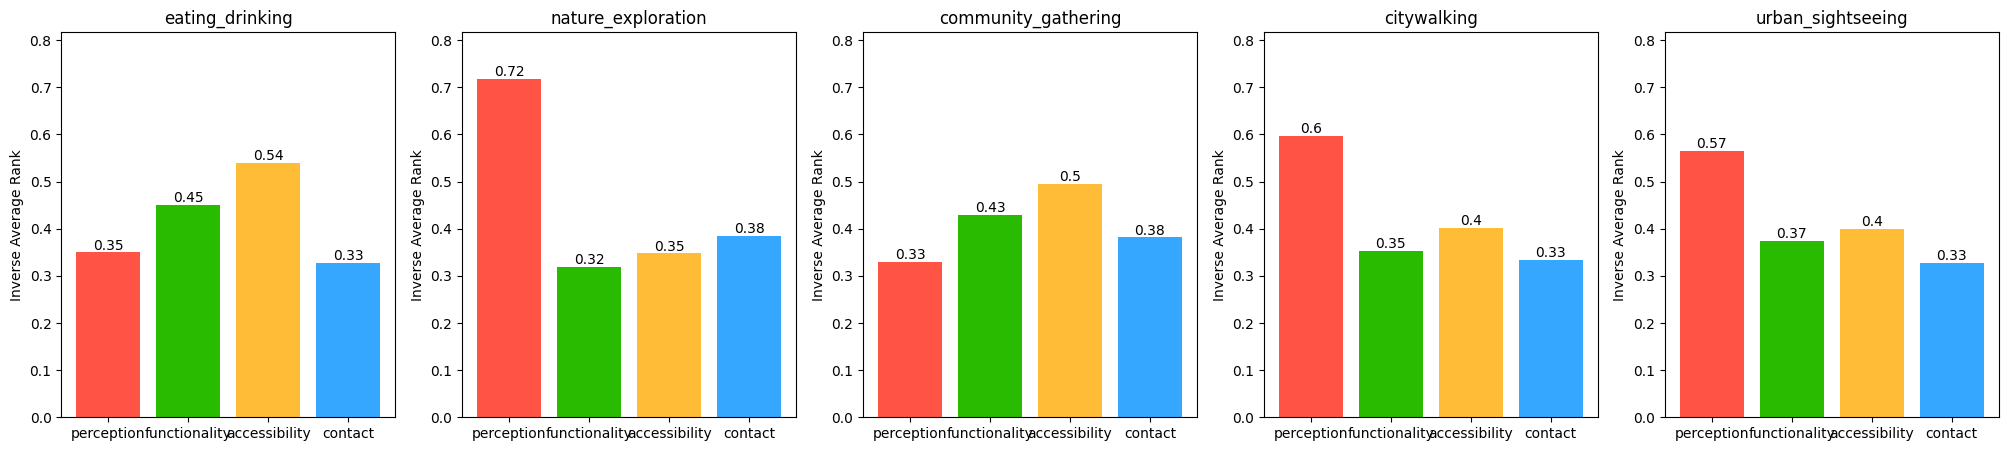

In [18]:
# 1.1 Load Survey Data and Define Labels
final_survey_df = pd.read_csv('data/data_resident_survey_results.csv')

# Print columns to check the format
print("Columns:", final_survey_df.columns)

# Print number of total responses
print("Responses:", final_survey_df.shape[0])

space_categories = ['streetscape_perception', 'functionality', 'accessibility', 'contact_density']
activity_submark = ['eating', 'nature', 'community', 'citywalking', 'sightseeing']

activity_categories = ['eating_drinking', 'nature_exploration', 'community_gathering', 'citywalking', 'urban_sightseeing']
space_submark = ['perception', 'functionality', 'accessibility', 'contact']

colors = ['#FF5445', '#29BB00', '#FFBC37', '#35A7FF', '#B339FF']

def calculate_average_ranking(column_name, subcategory_mark):
    # Calculate average ranking for each subcategory
    rankings_single_column = {category: [] for category in subcategory_mark}
    for ranking in final_survey_df[column_name]:
        rank_list = ranking.split(",")
        for rank, category in enumerate(rank_list, start=1):
            rankings_single_column[category].append(rank)

    # Calculate average values
    average_rankings_single_column = {k: np.mean(v) for k, v in rankings_single_column.items()}
    return average_rankings_single_column

def drawing_rankings(main, sub, dataset, ncols):
    # Create a row of bar charts, each representing a category with subcategories
    fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols*5, 5))  # Four subplots

    for i, category in enumerate(main):
        # Draw bars for each subcategory's inverse ranking
        axes[i].bar(sub, dataset[category], color=colors)
        axes[i].set_title(category)
        axes[i].set_ylim(0, max([max(vals) for vals in dataset.values()]) + 0.1)  # Ensure consistent y-axis
        axes[i].set_ylabel('Inverse Average Rank')
        
        # Add value labels
        for j, val in enumerate(dataset[category]):
            axes[i].text(j, val, round(val, 2), ha='center', va='bottom', color='black')

    plt.show()

rankings_of_activity = {}
rankings_of_space = {}

for category in space_categories:
    ranking_list = [v for k, v in calculate_average_ranking(category, activity_submark).items()]
    rankings_of_activity[category] = ranking_list

print(rankings_of_activity)

for category in activity_categories:
    ranking_list = [v for k, v in calculate_average_ranking(category, space_submark).items()]
    rankings_of_space[category] = ranking_list

print(rankings_of_space)

# Calculate the inverse of rankings to represent importance
inverse_data_1 = {category: [1/v for v in values] for category, values in rankings_of_activity.items()}
inverse_data_2 = {category: [1/v for v in values] for category, values in rankings_of_space.items()}

drawing_rankings(space_categories, activity_submark, inverse_data_1, 4)
drawing_rankings(activity_categories, space_submark, inverse_data_2, 5)

## 2. Resident Survey Processing

Transform and normalize resident-survey responses from two methods, then build a combined resident baseline.


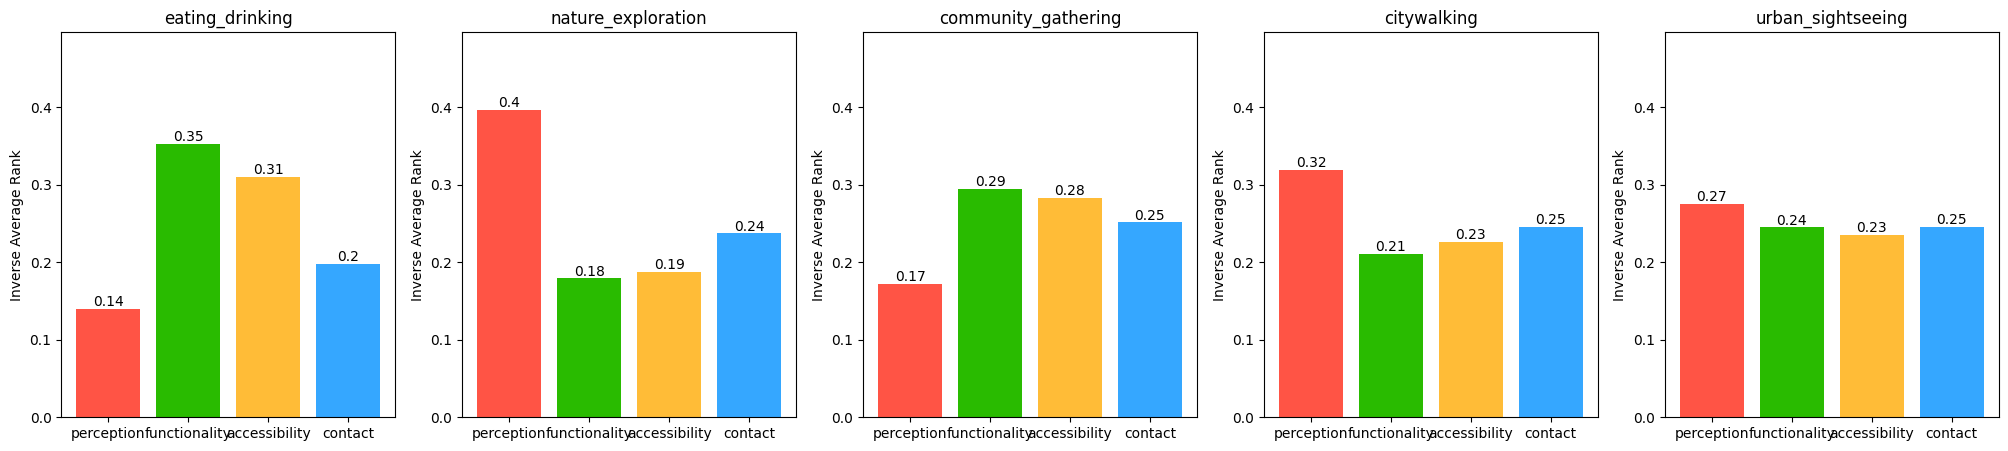

In [19]:
# 2.1 Transform and Normalize Resident Survey (Method 1)
# First create a new data structure that reverses the relationship between space categories and activity categories
inverse_data_1_transposed = {}

# Initialize dictionary with an empty list for each activity category
for activity in activity_submark:
    inverse_data_1_transposed[activity] = []

# Fill data: For each space category, add its corresponding activity importance value to the appropriate activity list
for space_category in space_categories:
    for i, activity in enumerate(activity_submark):
        inverse_data_1_transposed[activity].append(inverse_data_1[space_category][i])

# Normalize inverse_data_1_transposed so that the sum of space importance values equals 1 for each activity category
normalized_inverse_data_1 = {}

for activity, values in inverse_data_1_transposed.items():
    # Calculate total
    total = sum(values)
    # Normalize to make sum equal to 1
    normalized_inverse_data_1[activity] = [v/total for v in values]

# Create new normalized data structure with renamed categories
normalized_inverse_data_1_renamed = {}
for activity_sub in activity_submark:
    # Get corresponding activity category name from activity_categories
    activity_cat = activity_categories[activity_submark.index(activity_sub)]
    normalized_inverse_data_1_renamed[activity_cat] = normalized_inverse_data_1[activity_sub]

# Visualize the normalized results using the drawing_rankings function with renamed categories
drawing_rankings(activity_categories, space_submark, normalized_inverse_data_1_renamed, 5)

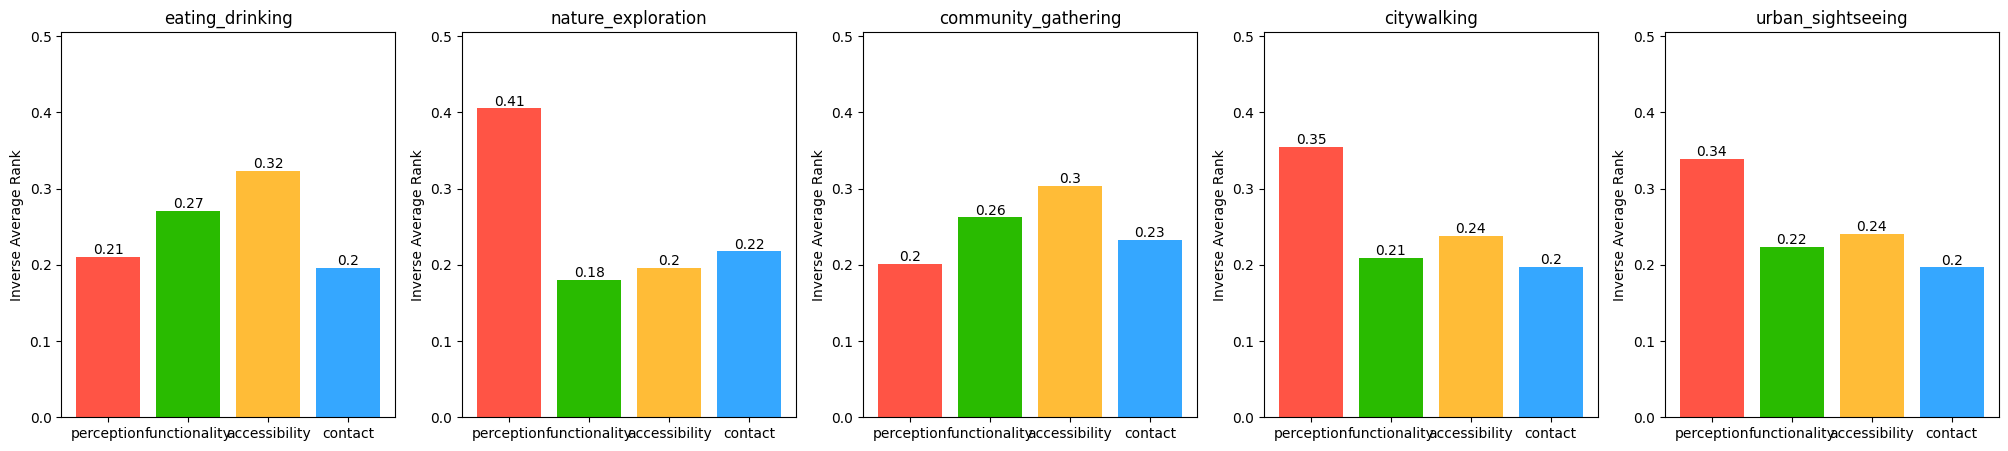

In [20]:
# 2.2 Normalize Resident Survey (Method 2)
normalized_inverse_data_2 = {}

for category, values in inverse_data_2.items():
    # Calculate sum
    total = sum(values)
    # Normalize to make sum equal to 1 
    normalized_inverse_data_2[category] = [v/total for v in values]

# Visualize the normalized results
drawing_rankings(activity_categories, space_submark, normalized_inverse_data_2, 5)

plt.show()


Average weights for eating_drinking:
perception: 0.175
functionality: 0.312
accessibility: 0.317
contact: 0.197

Average weights for nature_exploration:
perception: 0.401
functionality: 0.180
accessibility: 0.192
contact: 0.227

Average weights for community_gathering:
perception: 0.187
functionality: 0.278
accessibility: 0.293
contact: 0.242

Average weights for citywalking:
perception: 0.336
functionality: 0.210
accessibility: 0.232
contact: 0.222

Average weights for urban_sightseeing:
perception: 0.307
functionality: 0.234
accessibility: 0.237
contact: 0.221


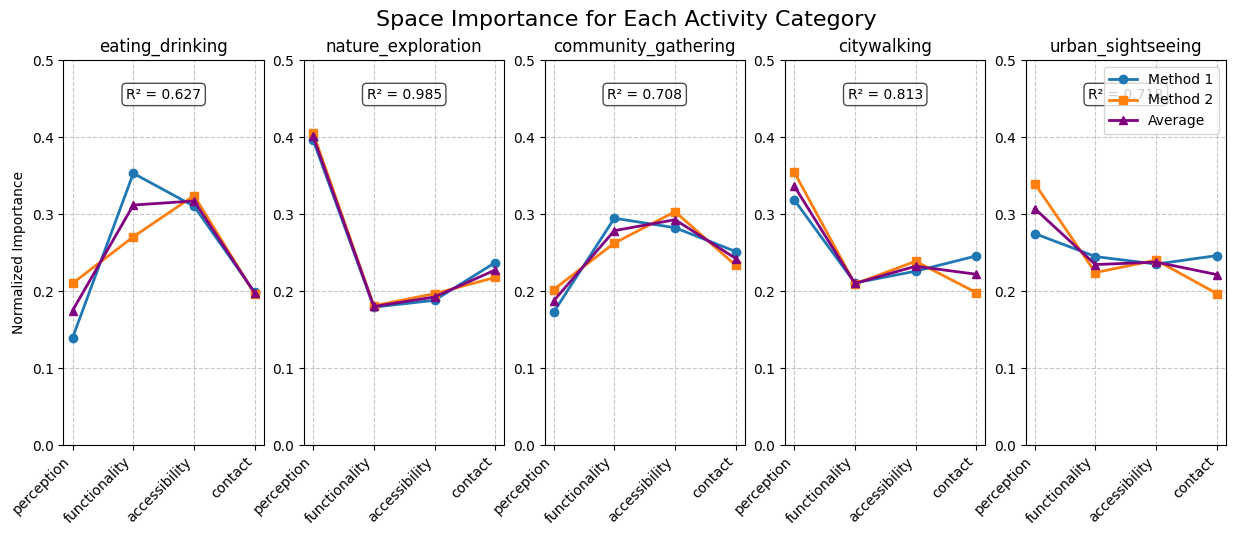

In [21]:
# 2.3 Combine Resident Methods and Visual Diagnostics
# Create separate subplots for each activity category using line charts

# Import scipy.stats for calculating R²
from scipy import stats

# Calculate the average of both methods to create normalized_resident_data
normalized_resident_data = {}
for activity in activity_categories:
    data1 = normalized_inverse_data_1_renamed[activity]
    data2 = normalized_inverse_data_2[activity]
    # Calculate average of both methods
    normalized_resident_data[activity] = [(d1 + d2) / 2 for d1, d2 in zip(data1, data2)]
    # Print average weights for each activity
    print(f"\nAverage weights for {activity}:")
    for i, weight in enumerate(normalized_resident_data[activity]):
        print(f"{space_submark[i]}: {weight:.3f}")

# Get the number of activity categories
n_activities = len(activity_categories)

# Create a figure with n_activities subplots, one for each activity category
fig, axes = plt.subplots(1, n_activities, figsize=(15, 5))

# Iterate through each activity category
for i, activity in enumerate(activity_categories):
    ax = axes[i]
    
    # Get data for this activity category from both datasets
    data1 = normalized_inverse_data_1_renamed[activity]
    data2 = normalized_inverse_data_2[activity]
    data_avg = normalized_resident_data[activity]
    
    # Set x-axis positions
    x = np.arange(len(space_submark))
    
    # Plot line charts for both datasets and the average
    ax.plot(x, data1, 'o-', linewidth=2, markersize=6, label='Method 1')
    ax.plot(x, data2, 's-', linewidth=2, markersize=6, label='Method 2')
    ax.plot(x, data_avg, '^-', linewidth=2, markersize=6, label='Average', color='purple')
    
    # Set title and labels
    ax.set_title(f'{activity}')
    ax.set_xticks(x)
    ax.set_xticklabels(space_submark, rotation=45, ha='right')
    
    # Set uniform y-axis range from 0 to 0.5
    ax.set_ylim(0, 0.5)
    
    # Only show y-axis label on the first subplot
    if i == 0:
        ax.set_ylabel('Normalized Importance')
    
    # Only show legend on the last subplot
    if i == n_activities - 1:
        ax.legend(loc='upper right')
    
    # Add grid lines
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Calculate R² between the two weight results
    # Calculate linear regression R²
    slope, intercept, r_value, p_value, std_err = stats.linregress(data1, data2)
    r_squared = r_value**2
    
    # Display R² value on the plot
    ax.text(0.5, 0.9, f'R² = {r_squared:.3f}', 
            transform=ax.transAxes, ha='center', 
            bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

# Add overall title
plt.suptitle('Space Importance for Each Activity Category', fontsize=16)
plt.show()


## 3. Expert Survey Result

Aggregate expert-provided weights for each activity and produce normalized expert profiles.


In [22]:
# 3.1 Build and Aggregate Expert Weights
expert_weights = {
    'eating_drinking': [
        [0.20, 0.35, 0.25, 0.20],  # UrbanPlaner1
        [0.20, 0.40, 0.30, 0.10],  # UrbanPlaner2 
        [0.15, 0.40, 0.25, 0.20],  # UrbanPlaner3
        [0.25, 0.30, 0.25, 0.20],  # UrbanPlaner4
        [0.25, 0.35, 0.25, 0.15],  # Architect1
        [0.25, 0.35, 0.25, 0.15],  # Architect2
        [0.25, 0.35, 0.25, 0.15],  # GISDataScientist1
        [0.25, 0.35, 0.25, 0.15],  # GISDataScientist2
        [0.20, 0.35, 0.30, 0.15],  # PolicyMaker1
        [0.25, 0.40, 0.20, 0.15],  # PolicyMaker2
        [0.20, 0.40, 0.25, 0.15],  # Professor1
        [0.25, 0.35, 0.25, 0.15],  # Professor2
        [0.20, 0.40, 0.25, 0.15],  # EnvironmentalConsultant1
        [0.20, 0.40, 0.25, 0.15],  # RealEstateDeveloper1
        [0.25, 0.30, 0.25, 0.20],  # RealEstateInvestmentConsultant1
    ],
    'nature_exploration': [
        [0.40, 0.10, 0.35, 0.15],  # UrbanPlaner1
        [0.30, 0.10, 0.30, 0.30],  # UrbanPlaner2
        [0.40, 0.10, 0.30, 0.20],  # UrbanPlaner3
        [0.40, 0.10, 0.20, 0.30],  # UrbanPlaner4
        [0.30, 0.10, 0.20, 0.40],  # Architect1
        [0.45, 0.10, 0.20, 0.25],  # Architect2
        [0.30, 0.10, 0.25, 0.35],  # GISDataScientist1
        [0.45, 0.10, 0.30, 0.15],  # GISDataScientist2
        [0.40, 0.15, 0.25, 0.20],  # PolicyMaker1
        [0.40, 0.10, 0.20, 0.30],  # PolicyMaker2
        [0.35, 0.10, 0.30, 0.25],  # Professor1
        [0.45, 0.10, 0.25, 0.20],  # Professor2
        [0.45, 0.10, 0.20, 0.25],  # EnvironmentalConsultant1
        [0.50, 0.10, 0.30, 0.10],  # RealEstateDeveloper1
        [0.35, 0.10, 0.25, 0.30],  # RealEstateInvestmentConsultant1
    ],
    'community_gathering': [
        [0.20, 0.25, 0.25, 0.30],  # UrbanPlaner1
        [0.20, 0.30, 0.20, 0.30],  # UrbanPlaner2
        [0.20, 0.25, 0.20, 0.35],  # UrbanPlaner3
        [0.20, 0.25, 0.25, 0.30],  # UrbanPlaner4
        [0.20, 0.30, 0.25, 0.25],  # Architect1
        [0.20, 0.25, 0.20, 0.35],  # Architect2
        [0.25, 0.20, 0.25, 0.30],  # GISDataScientist1
        [0.20, 0.30, 0.25, 0.25],  # GISDataScientist2
        [0.20, 0.30, 0.25, 0.25],  # PolicyMaker1
        [0.20, 0.30, 0.25, 0.25],  # PolicyMaker2
        [0.20, 0.25, 0.30, 0.25],  # Professor1
        [0.20, 0.25, 0.25, 0.30],  # Professor2
        [0.25, 0.25, 0.30, 0.20],  # EnvironmentalConsultant1
        [0.20, 0.30, 0.25, 0.25],  # RealEstateDeveloper1
        [0.20, 0.25, 0.25, 0.30],  # RealEstateInvestmentConsultant1
    ],
    'citywalking': [
        [0.35, 0.20, 0.25, 0.20],  # UrbanPlaner1
        [0.40, 0.10, 0.30, 0.20],  # UrbanPlaner2
        [0.35, 0.15, 0.35, 0.15],  # UrbanPlaner3
        [0.40, 0.15, 0.25, 0.20],  # UrbanPlaner4
        [0.40, 0.20, 0.20, 0.20],  # Architect1
        [0.35, 0.20, 0.25, 0.20],  # Architect2
        [0.35, 0.15, 0.25, 0.25],  # GISDataScientist1
        [0.35, 0.15, 0.30, 0.20],  # GISDataScientist2
        [0.30, 0.30, 0.20, 0.20],  # PolicyMaker1
        [0.35, 0.15, 0.25, 0.25],  # PolicyMaker2
        [0.40, 0.15, 0.25, 0.20],  # Professor1
        [0.40, 0.15, 0.25, 0.20],  # Professor2
        [0.45, 0.10, 0.25, 0.20],  # EnvironmentalConsultant1
        [0.45, 0.15, 0.25, 0.15],  # RealEstateDeveloper1
        [0.35, 0.15, 0.20, 0.30],  # RealEstateInvestmentConsultant1
    ],
    'urban_sightseeing': [
        [0.30, 0.25, 0.25, 0.20],  # UrbanPlaner1
        [0.40, 0.20, 0.30, 0.10],  # UrbanPlaner2
        [0.30, 0.25, 0.30, 0.15],  # UrbanPlaner3
        [0.35, 0.20, 0.25, 0.20],  # UrbanPlaner4
        [0.35, 0.25, 0.25, 0.15],  # Architect1
        [0.40, 0.20, 0.25, 0.15],  # Architect2
        [0.30, 0.20, 0.30, 0.20],  # GISDataScientist1
        [0.40, 0.15, 0.30, 0.15],  # GISDataScientist2
        [0.35, 0.20, 0.30, 0.15],  # PolicyMaker1
        [0.35, 0.20, 0.30, 0.15],  # PolicyMaker2
        [0.35, 0.15, 0.35, 0.15],  # Professor1
        [0.35, 0.30, 0.25, 0.10],  # Professor2
        [0.35, 0.20, 0.25, 0.20],  # EnvironmentalConsultant1
        [0.35, 0.25, 0.25, 0.15],  # RealEstateDeveloper1
        [0.30, 0.20, 0.30, 0.20],  # RealEstateInvestmentConsultant1
    ]
}

# Calculate the average weight for each activity
normalized_expert_data = {}
for activity in expert_weights:
    # Calculate the average for each dimension
    weights = expert_weights[activity]
    n_experts = len(weights)
    average_weights = [sum(dim)/n_experts for dim in zip(*weights)]
    normalized_expert_data[activity] = average_weights

# Print the result
print(normalized_expert_data)

{'eating_drinking': [0.22333333333333336, 0.36333333333333334, 0.2533333333333333, 0.15999999999999998], 'nature_exploration': [0.3933333333333333, 0.10333333333333336, 0.25666666666666665, 0.24666666666666667], 'community_gathering': [0.2066666666666667, 0.26666666666666666, 0.24666666666666662, 0.28], 'citywalking': [0.3766666666666667, 0.1633333333333333, 0.25333333333333335, 0.20666666666666667], 'urban_sightseeing': [0.3466666666666666, 0.21333333333333332, 0.28, 0.16]}


## 4. Triangulated Comparison

Compare causal, resident, and expert weight structures activity-by-activity, and visualize their agreement patterns.



Activity: eating_drinking
Causal Analysis: [0.21443904026913177, 0.23139494096355737, 0.25166987986195793, 0.3024961389053529]
Resident Survey: [0.17459797687202655, 0.3115508970831702, 0.31686959008155163, 0.1969815359632516]
Expert Evaluation: [0.22333333333333336, 0.36333333333333334, 0.2533333333333333, 0.15999999999999998]
Average: [0.2041234501581639, 0.30209305712668694, 0.27395760109228096, 0.21982589162286814]

Activity: nature_exploration
Causal Analysis: [0.2341801784665347, 0.1907692809099369, 0.16646079443624012, 0.4085897461872883]
Resident Survey: [0.40075018651689454, 0.1798313607939108, 0.19218087454211055, 0.227237578147084]
Expert Evaluation: [0.3933333333333333, 0.10333333333333336, 0.25666666666666665, 0.24666666666666667]
Average: [0.3427545661055875, 0.15797799167906035, 0.2051027785483391, 0.29416466366701305]

Activity: community_gathering
Causal Analysis: [0.16308844164766229, 0.26540132006919337, 0.24977111008505962, 0.3217391281980847]
Resident Survey: [0.1

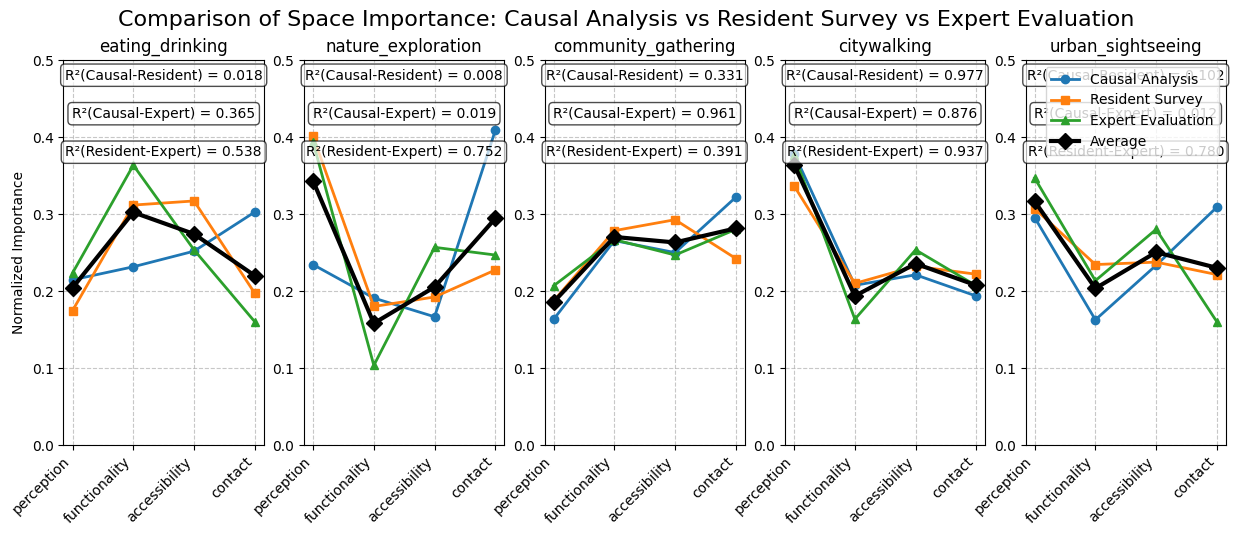

Saved average activity weights to: data/data_uci_hybrid_weighting.json
Activity labels: ['eating', 'nature', 'community', 'walking', 'sightseeing']


In [23]:
# 4.1 Compare Causal / Resident / Expert Weights

# Expect normalized_causal_importance from the previous normalized-dimension module (2f)
if "normalized_causal_importance" not in globals():
    import json
    from pathlib import Path

    causal_json_path = Path("data/data_uci_dimension_causal_importance.json")
    if not causal_json_path.exists():
        raise RuntimeError(
            "normalized_causal_importance not found in memory and JSON file is missing: "
            f"{causal_json_path}. Please run Part 2 export cell first."
        )

    with causal_json_path.open("r", encoding="utf-8") as f:
        normalized_causal_importance = json.load(f)

    print(f"Loaded normalized_causal_importance from: {causal_json_path}")

# Create line plots to compare causal analysis, resident survey and expert evaluation results

# Map Part-3 activity names to Part-2 causal keys
causal_activity_map = {
    "eating_drinking": "eating",
    "nature_exploration": "nature",
    "community_gathering": "community",
    "citywalking": "walking",
    "urban_sightseeing": "sightseeing",
}

# Get number of activity categories
n_activities = len(activity_categories)

# Print average values for each activity
for activity in activity_categories:
    print(f"\nActivity: {activity}")
    causal_key = causal_activity_map.get(activity, activity)
    print("Causal Analysis:", normalized_causal_importance[causal_key])
    print("Resident Survey:", normalized_resident_data[activity]) 
    print("Expert Evaluation:", normalized_expert_data[activity])
    
    # Calculate and print average
    average_data = [(c + r + e)/3 for c, r, e in zip(normalized_causal_importance[causal_key], 
                                                    normalized_resident_data[activity],
                                                    normalized_expert_data[activity])]
    print("Average:", average_data)

# Create a figure with one subplot per activity category 
fig, axes = plt.subplots(1, n_activities, figsize=(15, 5))

# Loop through each activity category
for i, activity in enumerate(activity_categories):
    ax = axes[i]
    
    # Get data for this activity category
    causal_key = causal_activity_map.get(activity, activity)
    causal_data = normalized_causal_importance[causal_key]
    resident_data = normalized_resident_data[activity]
    expert_data = normalized_expert_data[activity]
    
    # Calculate average of three methods
    average_data = [(c + r + e)/3 for c, r, e in zip(causal_data, resident_data, expert_data)]
    
    # Set x-axis positions
    x = np.arange(len(space_submark))
    
    # Plot line graphs for all datasets
    ax.plot(x, causal_data, 'o-', linewidth=2, markersize=6, label='Causal Analysis')
    ax.plot(x, resident_data, 's-', linewidth=2, markersize=6, label='Resident Survey')
    ax.plot(x, expert_data, '^-', linewidth=2, markersize=6, label='Expert Evaluation')
    ax.plot(x, average_data, 'D-', linewidth=3, markersize=8, label='Average', color='black')
    
    # Set title and labels
    ax.set_title(f'{activity}')
    ax.set_xticks(x)
    ax.set_xticklabels(space_submark, rotation=45, ha='right')
    
    # Set uniform y-axis range
    ax.set_ylim(0, 0.5)
    
    # Only show y-axis label on first subplot
    if i == 0:
        ax.set_ylabel('Normalized Importance')
    
    # Only show legend on last subplot
    if i == n_activities - 1:
        ax.legend(loc='upper right')
    
    # Add grid lines
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # Calculate R² between causal and resident results
    slope, intercept, r_value, p_value, std_err = stats.linregress(causal_data, resident_data)
    r_squared_resident = r_value**2
    
    # Calculate R² between causal and expert results
    slope, intercept, r_value, p_value, std_err = stats.linregress(causal_data, expert_data)
    r_squared_expert = r_value**2
    
    # Calculate R² between resident and expert results
    slope, intercept, r_value, p_value, std_err = stats.linregress(resident_data, expert_data)
    r_squared_resident_expert = r_value**2
    
    # Display R² values on plot
    ax.text(0.5, 0.95, f'R²(Causal-Resident) = {r_squared_resident:.3f}', 
            transform=ax.transAxes, ha='center', 
            bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    ax.text(0.5, 0.85, f'R²(Causal-Expert) = {r_squared_expert:.3f}',
            transform=ax.transAxes, ha='center',
            bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))
    ax.text(0.5, 0.75, f'R²(Resident-Expert) = {r_squared_resident_expert:.3f}',
            transform=ax.transAxes, ha='center',
            bbox=dict(facecolor='white', alpha=0.7, boxstyle='round'))

# Add overall title
plt.suptitle('Comparison of Space Importance: Causal Analysis vs Resident Survey vs Expert Evaluation', fontsize=16)
plt.show()

# 4.2 Save average weights with ACT-style activity labels
# key: eating/nature/community/walking/sightseeing
import json
from pathlib import Path

average_activity_weights = {}
for activity in activity_categories:
    causal_key = causal_activity_map.get(activity, activity)
    causal_data = normalized_causal_importance[causal_key]
    resident_data = normalized_resident_data[activity]
    expert_data = normalized_expert_data[activity]
    average_data = [(c + r + e) / 3 for c, r, e in zip(causal_data, resident_data, expert_data)]
    average_activity_weights[causal_key] = average_data

avg_export_path = Path('data/data_uci_hybrid_weighting.json')
avg_export_path.parent.mkdir(parents=True, exist_ok=True)
with avg_export_path.open('w', encoding='utf-8') as f:
    json.dump(average_activity_weights, f, ensure_ascii=False, indent=2)

print(f"Saved average activity weights to: {avg_export_path}")
print(f"Activity labels: {list(average_activity_weights.keys())}")
